In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [72]:
import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [73]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [74]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

In [75]:
train.shape

(2000, 8)

In [76]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [77]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [78]:
train.duplicated().sum()

np.int64(0)

In [79]:
#Class Distribution
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

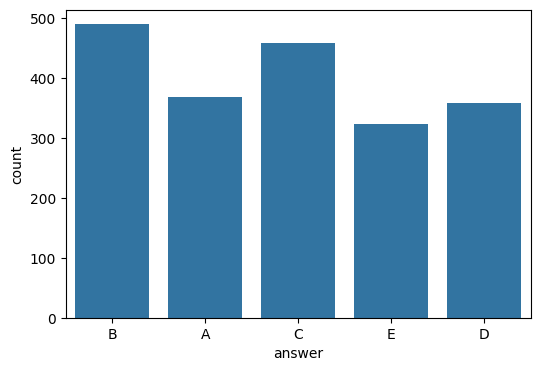

In [80]:
#class distribution plot
plt.figure(figsize=(6,4))

sns.countplot(x="answer",data=train)

plt.show()

In [81]:
#prompt length
train["prompt_length"] = train["prompt"].apply(len)

In [82]:
train["prompt_length"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_length, dtype: float64

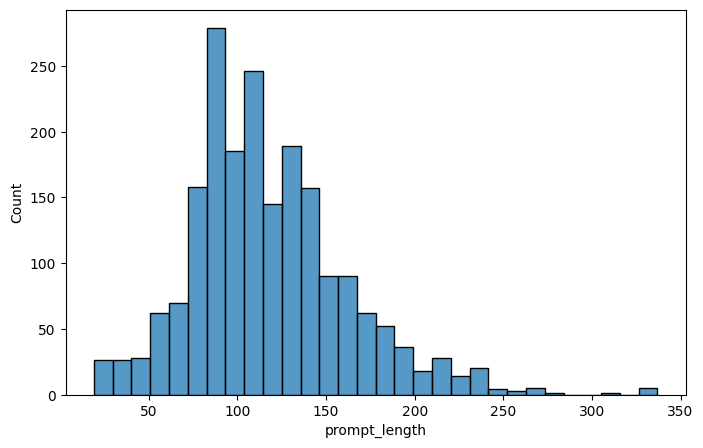

In [83]:
plt.figure(figsize=(8,5))

sns.histplot(train["prompt_length"],bins=30)

plt.show()

In [84]:
train.iloc[0]

id                                                               1
prompt           Pick the best possible answer: What is Martin ...
A                Martin Heidegger believes that humans exist wi...
B                Martin Heidegger believes that humans do not e...
C                Martin Heidegger does not believe in the exist...
D                Martin Heidegger believes that the relationshi...
E                Martin Heidegger believes that time is an illu...
answer                                                           B
prompt_length                                                  142
Name: 0, dtype: object

In [85]:
# Calculate length of each option

for col in ["A", "B", "C", "D", "E"]:
    train[f"{col}_length"] = train[col].astype(str).apply(len)

In [86]:
option_length_stats = train[
    ["A_length", "B_length", "C_length", "D_length", "E_length"]
].describe()

display(option_length_stats)

,A_length,B_length,C_length,D_length,E_length
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


In [87]:
#Class Percentages
answer_percentage = (
    train["answer"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

display(answer_percentage)

answer
A    18.45
B    24.50
C    22.95
D    17.90
E    16.20
Name: proportion, dtype: float64

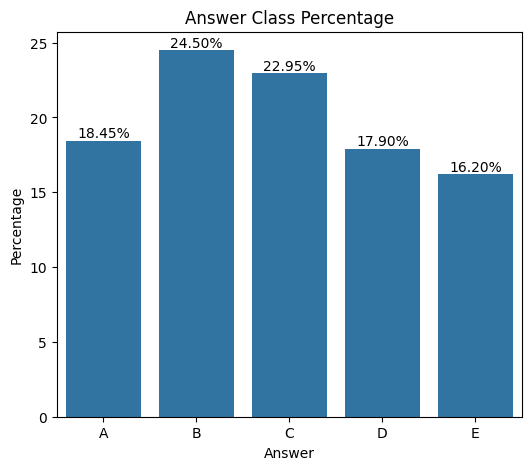

In [88]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=answer_percentage.index,
    y=answer_percentage.values
)

plt.title("Answer Class Percentage")
plt.xlabel("Answer")
plt.ylabel("Percentage")

for i, value in enumerate(answer_percentage.values):
    ax.text(i, value+0.2, f"{value:.2f}%", ha="center")

plt.show()

## EDA Observations

- Dataset contains approximately 2000 training samples and 500 test samples.
- No missing values or duplicate rows were observed.
- The answer classes (A–E) are nearly balanced, reducing the risk of class bias.
- Prompt lengths vary but most questions fall within a moderate character range.
- Option lengths are fairly consistent across all five choices, suggesting no significant length-based bias.
- The dataset appears clean and suitable for training without extensive preprocessing.

In [89]:
# Convert MCQs into binary samples
option_columns = ["A", "B", "C", "D", "E"]

train_samples = []

for _, row in train.iterrows():

    question = str(row["prompt"])

    correct = row["answer"]

    for option in option_columns:

        train_samples.append({

            "text": question + " [SEP] " + str(row[option]),

            "label": 1 if option == correct else 0,

            "option": option

        })

binary_train = pd.DataFrame(train_samples)

binary_train.head()

,text,label,option
0,Pick the best possible answer: What is Martin ...,0,A
1,Pick the best possible answer: What is Martin ...,1,B
2,Pick the best possible answer: What is Martin ...,0,C
3,Pick the best possible answer: What is Martin ...,0,D
4,Pick the best possible answer: What is Martin ...,0,E


In [90]:
binary_train.shape

(10000, 3)

In [91]:
binary_train["label"].value_counts()

label
0    8000
1    2000
Name: count, dtype: int64

In [119]:
from sklearn.model_selection import train_test_split

# Keep original MCQ split for evaluation
train_original, val_original = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["answer"]
)

# Convert original train MCQs into binary samples
train_samples = []

for _, row in train_original.iterrows():

    question = str(row["prompt"])
    correct = row["answer"]

    for option in option_columns:

        train_samples.append({
            "text": question + " [SEP] " + str(row[option]),
            "label": 1 if option == correct else 0,
            "option": option
        })

train_df = pd.DataFrame(train_samples)

# Convert original validation MCQs into binary samples
val_samples = []

for _, row in val_original.iterrows():

    question = str(row["prompt"])
    correct = row["answer"]

    for option in option_columns:

        val_samples.append({
            "text": question + " [SEP] " + str(row[option]),
            "label": 1 if option == correct else 0,
            "option": option
        })

val_df = pd.DataFrame(val_samples)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Original Validation:", val_original.shape)

Train: (8000, 3)
Validation: (2000, 3)
Original Validation: (400, 14)


In [120]:
# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

MAX_FEATURES = 5000

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=MAX_FEATURES,
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(train_df["text"])

X_val = vectorizer.transform(val_df["text"])

y_train = train_df["label"].values
y_val = val_df["label"].values

print(X_train.shape)
print(X_val.shape)

(8000, 5000)
(2000, 5000)


In [121]:
import torch
import torch.nn as nn

X_train = torch.tensor(
    X_train.toarray(),
    dtype=torch.float32
)

X_val = torch.tensor(
    X_val.toarray(),
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_val = torch.tensor(
    y_val,
    dtype=torch.float32
)

print(X_train.shape)

torch.Size([8000, 5000])


In [122]:
#TensorDataset
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

In [123]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [124]:
batch = next(iter(train_loader))

print(batch[0].shape)
print(batch[1].shape)

torch.Size([64, 5000])
torch.Size([64])


**from scratch model (feed forward NN)**

In [125]:
class FeedForwardNN(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim,1024),

            nn.BatchNorm1d(1024),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(1024,512),

            nn.BatchNorm1d(512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512,128),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128,1)

        )

    def forward(self,x):

        return self.network(x)

In [126]:
import torch

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [127]:
INPUT_DIM = X_train.shape[1]

model = FeedForwardNN(INPUT_DIM)

model = model.to(device)

print(model)

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=5000, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=128, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [128]:
!pip install -q wandb

In [129]:
import wandb

wandb.login()

True

In [130]:
wandb.init(
    project="Smart-MCQ-Solver",
    name="FFNN-TFIDF",
    config={
        "epochs": 10,
        "batch_size": 64,
        "learning_rate": 1e-3,
        "optimizer": "Adam",
        "architecture": "FeedForwardNN"
    }
)

In [131]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0

    predictions = []
    labels = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        predictions.extend(preds.cpu().numpy().astype(int))
        labels.extend(y_batch.cpu().numpy().astype(int))

    epoch_loss = running_loss / len(loader)

    epoch_acc = accuracy_score(labels, predictions)

    epoch_f1 = f1_score(labels, predictions)

    return epoch_loss, epoch_acc, epoch_f1

In [132]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0

    predictions = []
    labels = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch).squeeze()

            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).float()

            predictions.extend(preds.cpu().numpy().astype(int))
            labels.extend(y_batch.cpu().numpy().astype(int))

    epoch_loss = running_loss / len(loader)

    epoch_acc = accuracy_score(labels, predictions)

    epoch_f1 = f1_score(labels, predictions)

    return epoch_loss, epoch_acc, epoch_f1

In [133]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [134]:
EPOCHS = 10

best_val_f1 = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

for epoch in range(EPOCHS):

    # -------------------- TRAIN --------------------
    train_loss, train_acc, train_f1 = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion
    )

    # ------------------ VALIDATE -------------------
    val_loss, val_acc, val_f1 = validate(
        model=model,
        loader=val_loader,
        criterion=criterion
    )

    # Update learning rate scheduler
    scheduler.step(val_f1)

    # Save metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    # Log to WandB
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_loss": val_loss,
        "train_accuracy": train_acc,
        "validation_accuracy": val_acc,
        "train_f1": train_f1,
        "validation_f1": val_f1,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    print("=" * 70)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Validation Acc  : {val_acc:.4f}")
    print(f"Train F1 Score  : {train_f1:.4f}")
    print(f"Validation F1   : {val_f1:.4f}")
    print("=" * 70)

    # Save best model
    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            model.state_dict(),
            "model1_ffnn.pth"
        )

        print("✅ Best model saved!\n")

print(f"\nTraining Completed!")
print(f"Best Validation F1 : {best_val_f1:.4f}")

Epoch 1/10
Train Loss      : 0.4840
Validation Loss : 0.3692
Train Accuracy  : 0.7960
Validation Acc  : 0.8300
Train F1 Score  : 0.0297
Validation F1   : 0.2797
✅ Best model saved!

Epoch 2/10
Train Loss      : 0.3279
Validation Loss : 0.2656
Train Accuracy  : 0.8612
Validation Acc  : 0.8800
Train F1 Score  : 0.5383
Validation F1   : 0.5848
✅ Best model saved!

Epoch 3/10
Train Loss      : 0.2530
Validation Loss : 0.2301
Train Accuracy  : 0.8909
Validation Acc  : 0.8955
Train F1 Score  : 0.6570
Validation F1   : 0.6624
✅ Best model saved!

Epoch 4/10
Train Loss      : 0.2249
Validation Loss : 0.1933
Train Accuracy  : 0.9034
Validation Acc  : 0.9190
Train F1 Score  : 0.7130
Validation F1   : 0.7477
✅ Best model saved!

Epoch 5/10
Train Loss      : 0.1997
Validation Loss : 0.1860
Train Accuracy  : 0.9157
Validation Acc  : 0.9210
Train F1 Score  : 0.7517
Validation F1   : 0.7697
✅ Best model saved!

Epoch 6/10
Train Loss      : 0.1850
Validation Loss : 0.1536
Train Accuracy  : 0.9199
Vali

In [135]:
import os

print(os.listdir("/kaggle/working"))

['bilstm_vocab.pkl', 'wandb', 'submission.csv', 'model2_bilstm.pth', 'model1_ffnn.pth', 'tfidf_vectorizer.pkl', '.virtual_documents']


In [136]:
import joblib

joblib.dump(
    vectorizer,
    "/kaggle/working/tfidf_vectorizer.pkl"
)

['/kaggle/working/tfidf_vectorizer.pkl']

In [137]:
print(os.listdir("/kaggle/working"))

['bilstm_vocab.pkl', 'wandb', 'submission.csv', 'model2_bilstm.pth', 'model1_ffnn.pth', 'tfidf_vectorizer.pkl', '.virtual_documents']


In [138]:
model.load_state_dict(torch.load("model1_ffnn.pth"))

model.eval()

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=5000, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=128, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [139]:
option_columns = ["A", "B", "C", "D", "E"]

test_samples = []

for _, row in test.iterrows():

    question = str(row["prompt"])

    for option in option_columns:

        test_samples.append({

            "id": row["id"],

            "option": option,

            "text": question + " [SEP] " + str(row[option])

        })

test_binary = pd.DataFrame(test_samples)

print(test_binary.shape)

test_binary.head()

(2500, 3)


,id,option,text
0,1,A,Pick the best possible answer: What is the rel...
1,1,B,Pick the best possible answer: What is the rel...
2,1,C,Pick the best possible answer: What is the rel...
3,1,D,Pick the best possible answer: What is the rel...
4,1,E,Pick the best possible answer: What is the rel...


In [140]:
wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,████████▁▁
train_accuracy,▁▄▆▆▇▇▇▇██
train_f1,▁▅▆▇▇▇████
train_loss,█▅▄▃▃▂▂▂▂▁
validation_accuracy,▁▄▅▆▆▇▇▇▇█
validation_f1,▁▅▆▇▇▇▇▇▇█
validation_loss,█▅▄▃▃▂▂▂▂▁
epoch,10
learning_rate,0.0005
train_accuracy,0.94225


In [141]:
# MAP@3 Function
import numpy as np

def map3_score(actual, predicted):

    score = 0.0

    for a, preds in zip(actual, predicted):

        if a == preds[0]:
            score += 1

        elif a == preds[1]:
            score += 0.5

        elif a == preds[2]:
            score += 1/3

    return score / len(actual)

In [142]:
option_columns = ["A","B","C","D","E"]

model.load_state_dict(torch.load("model1_ffnn.pth"))
model.eval()

val_predictions = []
actual_answers = []

for _, row in val_original.iterrows():

    scores = []

    for option in option_columns:

        text = row["prompt"] + " [SEP] " + row[option]

        x = vectorizer.transform([text])

        x = torch.tensor(
            x.toarray(),
            dtype=torch.float32
        ).to(device)

        with torch.no_grad():

            prob = torch.sigmoid(model(x)).item()

        scores.append(prob)

    ranked = np.argsort(scores)[::-1]

    preds = [option_columns[i] for i in ranked[:3]]

    val_predictions.append(preds)

    actual_answers.append(row["answer"])

map3_ffnn = map3_score(
    actual_answers,
    val_predictions
)

print("FFNN Validation MAP@3 :", map3_ffnn)

FFNN Validation MAP@3 : 0.9270833333333331


# MODEL 2 : Bidirectional LSTM

In [143]:
import gc

wandb.finish()

try:
    del model
    del optimizer
    del scheduler
    del criterion
except:
    pass

gc.collect()

torch.cuda.empty_cache()

print("Model 1 cleaned successfully.")

Model 1 cleaned successfully.


In [144]:
wandb.init(
    project="Smart-MCQ-Solver",
    name="Model2-BiLSTM",
    config={
        "architecture":"BiLSTM",
        "embedding_dim":128,
        "hidden_dim":128,
        "batch_size":64,
        "epochs":10,
        "max_length":128
    }
)

In [145]:
from collections import Counter
import re

counter = Counter()

for text in train_df["text"]:
    counter.update(re.findall(r"\b\w+\b", text.lower()))

vocab = {
    "<PAD>":0,
    "<UNK>":1
}

for word, freq in counter.items():

    if freq >= 2:

        vocab[word] = len(vocab)

print("Vocabulary Size :", len(vocab))

Vocabulary Size : 2979


In [146]:
# tokenizer
MAX_LEN = 128

def encode(text):

    words = re.findall(r"\b\w+\b", text.lower())

    ids = [
        vocab.get(word, vocab["<UNK>"])
        for word in words
    ]

    ids = ids[:MAX_LEN]

    if len(ids) < MAX_LEN:

        ids += [0] * (MAX_LEN-len(ids))

    return ids

In [147]:
from torch.utils.data import Dataset

class MCQDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe.reset_index(drop=True)

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        return (
            torch.tensor(
                encode(row["text"]),
                dtype=torch.long
            ),
            torch.tensor(
                row["label"],
                dtype=torch.float32
            )
        )

In [148]:
train_dataset = MCQDataset(train_df)
val_dataset = MCQDataset(val_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

In [149]:
# bilstm
class BiLSTMClassifier(nn.Module):

    def __init__(self,
                 vocab_size,
                 embedding_dim=128,
                 hidden_dim=128):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(
            hidden_dim*2,
            64
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            64,
            1
        )

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        forward = hidden[-2]

        backward = hidden[-1]

        x = torch.cat(
            (forward, backward),
            dim=1
        )

        x = self.dropout(x)

        x = self.relu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x.squeeze()

In [150]:
model = BiLSTMClassifier(
    vocab_size=len(vocab)
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(2979, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [151]:
from sklearn.metrics import accuracy_score, f1_score

def train_one_epoch_bilstm(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0

    predictions = []
    labels = []

    for inputs, targets in loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        predictions.extend(preds.cpu().numpy().astype(int))
        labels.extend(targets.cpu().numpy().astype(int))

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(labels, predictions)
    epoch_f1 = f1_score(labels, predictions)

    return epoch_loss, epoch_acc, epoch_f1

In [152]:
def validate_bilstm(model, loader, criterion):

    model.eval()

    running_loss = 0

    predictions = []
    labels = []

    with torch.no_grad():

        for inputs, targets in loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, targets)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).float()

            predictions.extend(preds.cpu().numpy().astype(int))
            labels.extend(targets.cpu().numpy().astype(int))

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(labels, predictions)
    epoch_f1 = f1_score(labels, predictions)

    return epoch_loss, epoch_acc, epoch_f1

In [153]:
EPOCHS = 10

best_val_f1 = 0.0

history_bilstm = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

for epoch in range(EPOCHS):

    train_loss, train_acc, train_f1 = train_one_epoch_bilstm(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc, val_f1 = validate_bilstm(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_f1)

    history_bilstm["train_loss"].append(train_loss)
    history_bilstm["val_loss"].append(val_loss)
    history_bilstm["train_acc"].append(train_acc)
    history_bilstm["val_acc"].append(val_acc)
    history_bilstm["train_f1"].append(train_f1)
    history_bilstm["val_f1"].append(val_f1)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_loss": val_loss,
        "train_accuracy": train_acc,
        "validation_accuracy": val_acc,
        "train_f1": train_f1,
        "validation_f1": val_f1
    })

    print("=" * 70)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Validation Acc  : {val_acc:.4f}")
    print(f"Train F1        : {train_f1:.4f}")
    print(f"Validation F1   : {val_f1:.4f}")
    print("=" * 70)

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(
            model.state_dict(),
            "model2_bilstm.pth"
        )

        print("✅ Best BiLSTM model saved.")

Epoch 1/10
Train Loss      : 0.5129
Validation Loss : 0.5015
Train Accuracy  : 0.8001
Validation Acc  : 0.8015
Train F1        : 0.0012
Validation F1   : 0.0149
✅ Best BiLSTM model saved.
Epoch 2/10
Train Loss      : 0.5027
Validation Loss : 0.4977
Train Accuracy  : 0.8010
Validation Acc  : 0.8015
Train F1        : 0.0100
Validation F1   : 0.0149
Epoch 3/10
Train Loss      : 0.5020
Validation Loss : 0.4977
Train Accuracy  : 0.8011
Validation Acc  : 0.8015
Train F1        : 0.0112
Validation F1   : 0.0149
Epoch 4/10
Train Loss      : 0.5011
Validation Loss : 0.4985
Train Accuracy  : 0.8011
Validation Acc  : 0.8015
Train F1        : 0.0112
Validation F1   : 0.0149
Epoch 5/10
Train Loss      : 0.5003
Validation Loss : 0.4971
Train Accuracy  : 0.8011
Validation Acc  : 0.8015
Train F1        : 0.0112
Validation F1   : 0.0149
Epoch 6/10
Train Loss      : 0.5003
Validation Loss : 0.4971
Train Accuracy  : 0.8011
Validation Acc  : 0.8015
Train F1        : 0.0112
Validation F1   : 0.0149
Epoch 7

In [154]:
wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▇████████
train_f1,▁▇████████
train_loss,█▃▂▂▁▁▁▁▁▁
validation_accuracy,▁▁▁▁▁▁▁▁▁▁
validation_f1,▁▁▁▁▁▁▁▁▁▁
validation_loss,█▂▂▃▁▁▁▁▁▁
epoch,10
train_accuracy,0.80112
train_f1,0.01119
train_loss,0.49961


In [155]:
# Save Vocabulary
import joblib

joblib.dump(vocab, "/kaggle/working/bilstm_vocab.pkl")

print("Vocabulary Saved")

Vocabulary Saved


In [156]:
option_columns = ["A", "B", "C", "D", "E"]

test_samples = []

for _, row in test.iterrows():

    question = str(row["prompt"])

    for option in option_columns:

        test_samples.append({
            "id": row["id"],
            "option": option,
            "text": question + " [SEP] " + str(row[option])
        })

test_binary = pd.DataFrame(test_samples)

print(test_binary.shape)

test_binary.head()

(2500, 3)


,id,option,text
0,1,A,Pick the best possible answer: What is the rel...
1,1,B,Pick the best possible answer: What is the rel...
2,1,C,Pick the best possible answer: What is the rel...
3,1,D,Pick the best possible answer: What is the rel...
4,1,E,Pick the best possible answer: What is the rel...


In [157]:
from torch.utils.data import Dataset

class TestDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        return torch.tensor(
            encode(row["text"]),    
            dtype=torch.long
        )

In [158]:
test_dataset = TestDataset(test_binary)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [159]:
# Predict Scores
scores = []

model.eval()

with torch.no_grad():

    for inputs in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        probs = torch.sigmoid(outputs)

        scores.extend(probs.cpu().numpy())

test_binary["score"] = scores

test_binary.head()

,id,option,text,score
0,1,A,Pick the best possible answer: What is the rel...,0.194572
1,1,B,Pick the best possible answer: What is the rel...,0.194572
2,1,C,Pick the best possible answer: What is the rel...,0.194572
3,1,D,Pick the best possible answer: What is the rel...,0.194572
4,1,E,Pick the best possible answer: What is the rel...,0.194572


In [160]:
# submission - Top-3 Predictions
submission = []

for question_id, group in test_binary.groupby("id"):

    top3 = (
        group
        .sort_values("score", ascending=False)
        .head(3)["option"]
        .tolist()
    )

    submission.append({
        "id": question_id,
        "Prediction": " ".join(top3)
    })

submission = pd.DataFrame(submission)

submission.head()

,id,Prediction
0,1,A B C
1,2,C E D
2,3,B A C
3,4,A B C
4,5,A B C


In [161]:
submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

In [162]:
print(submission.shape)

submission.head(10)

(500, 2)


,id,Prediction
0,1,A B C
1,2,C E D
2,3,B A C
3,4,A B C
4,5,A B C
5,6,E D C
6,7,E C A
7,8,E C B
8,9,A C E
9,10,A B C


In [163]:
model.load_state_dict(torch.load("model2_bilstm.pth"))

model.eval()

val_predictions = []
actual_answers = []

for _, row in val_original.iterrows():

    scores = []

    for option in option_columns:

        text = row["prompt"] + " [SEP] " + row[option]

        ids = torch.tensor(
            encode(text),
            dtype=torch.long
        ).unsqueeze(0).to(device)

        with torch.no_grad():

            prob = torch.sigmoid(model(ids)).item()

        scores.append(prob)

    ranked = np.argsort(scores)[::-1]

    preds = [option_columns[i] for i in ranked[:3]]

    val_predictions.append(preds)

    actual_answers.append(row["answer"])

map3_bilstm = map3_score(
    actual_answers,
    val_predictions
)

print("BiLSTM Validation MAP@3 :", map3_bilstm)

BiLSTM Validation MAP@3 : 0.3925


In [164]:
comparison = pd.DataFrame({

    "Model":[
        "Feed Forward NN",
        "BiLSTM"
    ],

    "Validation Accuracy":[
        history["val_acc"][-1],
        history_bilstm["val_acc"][-1]
    ],

    "Validation F1":[
        history["val_f1"][-1],
        history_bilstm["val_f1"][-1]
    ],

    "Validation MAP@3":[
        map3_ffnn,
        map3_bilstm
    ]

})

comparison

,Model,Validation Accuracy,Validation F1,Validation MAP@3
0,Feed Forward NN,0.9475,0.851485,0.927083
1,BiLSTM,0.8015,0.014888,0.392500


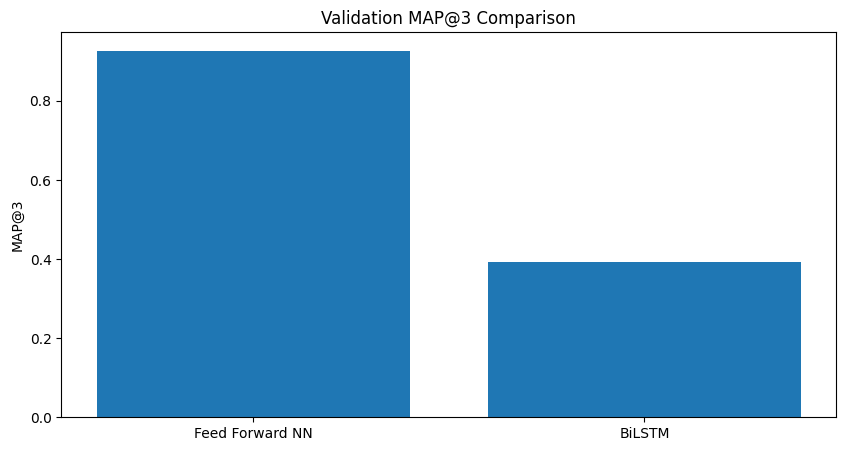

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    comparison["Model"],
    comparison["Validation MAP@3"]
)

plt.title("Validation MAP@3 Comparison")

plt.ylabel("MAP@3")

plt.show()